### DS223_Zhora Poghosyan_HW3

In [4]:
!pip install lifelines


  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4048 sha256=278e1cff0feb9fd87cb39e932d33bd0c9a17866dda1ddf6f177c5555d817fdb6
  Stored in directory: c:\users\bagrat_poghosyan\appdata\local\pip\cache\wheels\50\37\21\0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

from lifelines import (WeibullFitter, ExponentialFitter, LogNormalFitter, LogLogisticFitter,  
                        PiecewiseExponentialFitter, SplineFitter, MixtureCureFitter,
                        KaplanMeierFitter, NelsonAalenFitter, GeneralizedGammaFitter, BreslowFlemingHarringtonFitter)

from lifelines.utils import concordance_index

In [6]:
data = pd.read_csv("C:/Users/Bagrat_Poghosyan/Downloads/telco.csv")
data["event_observed"] = data["churn"].apply(lambda value: 1 if value == "Yes" else 0)

duration = data["tenure"]
event = data["event_observed"]

In [7]:
data.head()

,ID,region,tenure,age,marital,address,income,ed,retire,gender,voice,internet,forward,custcat,churn,event_observed
0,1,Zone 2,13,44,Married,9,64,College degree,No,Male,No,No,Yes,Basic service,Yes,1
1,2,Zone 3,11,33,Married,7,136,Post-undergraduate degree,No,Male,Yes,No,Yes,Total service,Yes,1
2,3,Zone 3,68,52,Married,24,116,Did not complete high school,No,Female,No,No,No,Plus service,No,0
3,4,Zone 2,33,33,Unmarried,12,33,High school degree,No,Female,No,No,No,Basic service,Yes,1
4,5,Zone 2,23,30,Married,9,30,Did not complete high school,No,Male,No,No,Yes,Plus service,No,0


### Weibull Fitter

In [8]:
weibull_model = WeibullFitter()
weibull_model.fit(duration, event, label="Weibull")
weibull_model.print_summary()

<lifelines.WeibullFitter:"Weibull", fitted with 1000 total observations, 726 right-censored observations>
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1606.43
               hypothesis = lambda_ != 1, rho_ != 1

---
          coef  se(coef)  coef lower 95%  coef upper 95%
lambda_ 138.09     12.38          113.82          162.36
rho_      0.95      0.05            0.85            1.05

         cmp to     z      p  -log2(p)
lambda_    1.00 11.07 <0.005     92.25
rho_       1.00 -1.07   0.29      1.80
---
AIC = 3216.86

### Exponetial Fitter

In [9]:
exp_model = ExponentialFitter()
exp_model.fit(duration, event, label="Exponential")
exp_model.print_summary()

<lifelines.ExponentialFitter:"Exponential", fitted with 1000 total observations, 726 right-censored observations>
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1606.98
               hypothesis = lambda_ != 0

---
          coef  se(coef)  coef lower 95%  coef upper 95%
lambda_ 129.66      7.83          114.30          145.01

         cmp to     z      p  -log2(p)
lambda_    0.00 16.55 <0.005    202.03
---
AIC = 3215.96

### LogNormal Fitter

In [10]:
lognorm_model = LogNormalFitter()
lognorm_model.fit(duration, event, label="LogNormal")
lognorm_model.print_summary()

<lifelines.LogNormalFitter:"LogNormal", fitted with 1000 total observations, 726 right-censored observations>
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1602.52
               hypothesis = mu_ != 0, sigma_ != 1

---
        coef  se(coef)  coef lower 95%  coef upper 95%
mu_     4.77      0.10            4.57            4.98
sigma_  1.81      0.09            1.64            1.97

        cmp to     z      p  -log2(p)
mu_       0.00 46.06 <0.005       inf
sigma_    1.00  9.37 <0.005     66.94
---
AIC = 3209.04

### LogLogistic Fitter

In [11]:
loglog_model = LogLogisticFitter()
loglog_model.fit(duration, event, label="LogLogistic")
loglog_model.print_summary()

<lifelines.LogLogisticFitter:"LogLogistic", fitted with 1000 total observations, 726 right-censored observations>
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1605.21
               hypothesis = alpha_ != 1, beta_ != 1

---
         coef  se(coef)  coef lower 95%  coef upper 95%
alpha_ 103.39      9.13           85.50          121.28
beta_    1.04      0.05            0.93            1.15

        cmp to     z      p  -log2(p)
alpha_    1.00 11.22 <0.005     94.60
beta_     1.00  0.73   0.46      1.11
---
AIC = 3214.42

### Kaplan-Meier Fitter

In [12]:
km_model = KaplanMeierFitter()
km_model.fit(duration, event, label="Kaplan-Meier")

<lifelines.KaplanMeierFitter:"Kaplan-Meier", fitted with 1000 total observations, 726 right-censored observations>

### Nelson-Aalen fitter

In [13]:
na_model = NelsonAalenFitter()
na_model.fit(duration, event, label="Nelson-Aalen")
na_model.survival_function_ = np.exp(-na_model.cumulative_hazard_)

### Generalized Gamma fitter

In [14]:
gg_model = GeneralizedGammaFitter()
gg_model.fit(duration, event, label="GeneralizedGamma")
gg_model.print_summary()

<lifelines.GeneralizedGammaFitter:"GeneralizedGamma", fitted with 1000 total observations, 726 right-censored observations>
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1602.50
               hypothesis = mu_ != 0, ln_sigma_ != 0, lambda_ != 1

---
           coef  se(coef)  coef lower 95%  coef upper 95%
mu_        4.79      0.14            4.51            5.06
ln_sigma_  0.57      0.14            0.29            0.85
lambda_    0.05      0.33           -0.60            0.70

           cmp to     z      p  -log2(p)
mu_          0.00 34.09 <0.005    843.87
ln_sigma_    0.00  4.02 <0.005     14.08
lambda_      1.00 -2.87 <0.005      7.92
---
AIC = 3211.01

### Spline Fitter

In [15]:
max_time = duration.max()
knot_locations = np.arange(0, max_time, 12)[1:]

spline_model = SplineFitter(knot_locations=knot_locations)
spline_model.fit(duration, event, label="Spline")
spline_model.print_summary()

<lifelines.SplineFitter:"Spline", fitted with 1000 total observations, 726 right-censored observations>
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1603.76
               hypothesis = phi_0_ != 0, phi_1_ != 0, phi_2_ != 0, phi_3_ != 0, phi_4_ != 0

---
        coef  se(coef)  coef lower 95%  coef upper 95%
phi_0_ -4.96      0.26           -5.47           -4.44
phi_1_  1.08      0.09            0.91            1.25
phi_2_  0.74      0.57           -0.38            1.86
phi_3_ -0.59      1.68           -3.90            2.71
phi_4_ -0.35      2.22           -4.71            4.00

        cmp to      z      p  -log2(p)
phi_0_    0.00 -18.89 <0.005    261.94
phi_1_    0.00  12.40 <0.005    114.92
phi_2_    0.00   1.30   0.19      2.37
phi_3_    0.00  -0.35   0.72      0.47
phi_4_    0.00  -0.16   0.87      0.20
---
AIC = 3217.52

### Piecewise Exponential fitter

In [16]:
breaks = [12, 24, 36, 48, 60]

pwexp_model = PiecewiseExponentialFitter(breaks)
pwexp_model.fit(duration, event, label="PiecewiseExponential")

<lifelines.PiecewiseExponentialFitter:"PiecewiseExponential", fitted with 1000 total observations, 726 right-censored observations>

### Mixture Cure Fitter

In [17]:
base_model = WeibullFitter()
mixture_cure_model = MixtureCureFitter(base_fitter=base_model)
mixture_cure_model.fit(duration, event, label="MixtureCure")
mixture_cure_model.print_summary()

<lifelines.MixtureCureFitter:"MixtureCure", fitted with 1000 total observations, 726 right-censored observations>
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1605.68
               hypothesis = cured_fraction_ != 0, lambda_ != 1, rho_ != 1

---
                 coef  se(coef)  coef lower 95%  coef upper 95%
cured_fraction_  0.38      0.16            0.07            0.69
lambda_         68.72     26.31           17.16          120.28
rho_             1.02      0.08            0.87            1.18

                 cmp to    z    p  -log2(p)
cured_fraction_    0.00 2.42 0.02      6.01
lambda_            1.00 2.57 0.01      6.64
rho_               1.00 0.31 0.76      0.40
---
AIC = 3217.36

### BFH Fitter

In [18]:
bfh_model = BreslowFlemingHarringtonFitter()
bfh_model.fit(duration, event, label="Breslow-Fleming-Harrington")

<lifelines.BreslowFlemingHarringtonFitter:"Breslow-Fleming-Harrington", fitted with 1000 total observations, 726 right-censored observations>

In [19]:
from lifelines.utils import concordance_index

def estimate_mean_survival(surv_func):
    time_deltas = surv_func.index.to_series().diff().fillna(0)
    return (surv_func.values.flatten() * time_deltas).sum()

models = [
    ("Weibull", weibull_model),
    ("Exponential", exp_model),
    ("LogNormal", lognorm_model),
    ("LogLogistic", loglog_model),
    ("Kaplan-Meier", km_model),
    ("Nelson-Aalen", na_model),
    ("GeneralizedGamma", gg_model),
    ("BFH", bfh_model),  # Make sure this model is fitted
    ("PiecewiseExponential", pwexp_model),
    ("Spline", spline_model),
    ("MixtureCure", mixture_cure_model)
]

comparison_data = []

for name, model in models:
    try:
        sf = model.survival_function_
        mean_time = estimate_mean_survival(sf)
    except Exception:
        mean_time = "Unavailable"

    comparison_data.append({
        "Model": name,
        "AIC": getattr(model, "AIC_", "N/A"),
        "Log-likelihood": getattr(model, "log_likelihood_", "N/A"),
        "Estimated Mean Survival Time": mean_time,
    })

comparison_df = pd.DataFrame(comparison_data).sort_values(
    by="Estimated Mean Survival Time", key=lambda x: pd.to_numeric(x, errors="coerce")
).reset_index(drop=True)

comparison_df

,Model,AIC,Log-likelihood,Estimated Mean Survival Time
0,GeneralizedGamma,3211.008906,-1602.504453,54.079730
1,LogNormal,3209.035147,-1602.517574,54.081357
2,LogLogistic,3214.415476,-1605.207738,54.092654
3,MixtureCure,3217.357137,-1605.678569,54.135988
4,Spline,3217.520743,-1603.760372,54.154521
5,Weibull,3216.861171,-1606.430585,54.177098
6,Exponential,3215.960813,-1606.980407,54.221759
7,PiecewiseExponential,3220.893222,-1604.446611,54.227262
8,Kaplan-Meier,N/A,N/A,54.883947
9,Nelson-Aalen,N/A,N/A,54.896867


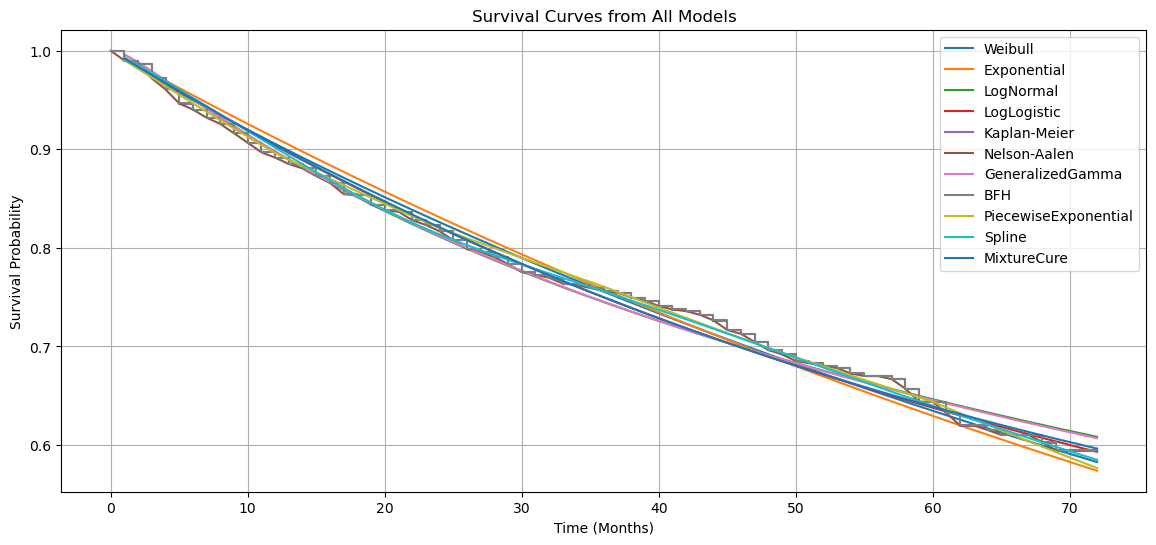

In [21]:
plt.figure(figsize=(14, 6))

for name, model in models:
    try:
        model.plot_survival_function(ci_show=False, label=name)
    except (AttributeError, NotImplementedError):
        if hasattr(model, "survival_function_"):
            plt.plot(
                model.survival_function_.index,
                model.survival_function_.values,
                label=name
            )

plt.title("Survival Curves from All Models")
plt.xlabel("Time (Months)")
plt.ylabel("Survival Probability")
plt.legend()
plt.grid(True)
plt.show()

## Model Selection

In evaluating various survival models, a thorough comparison based on key statistical metrics—namely, the Akaike Information Criterion (AIC) and the log-likelihood—was conducted to determine the most appropriate model for the dataset. Initially, the Generalized Gamma Fitter (GeneralizedGammaFitter) emerged as the top-performing model. It achieved the lowest AIC value, which typically indicates a better balance between model complexity and goodness of fit. Other models, such as the Log-Normal Fitter (LogNormalFitter), Weibull Fitter (WeibullFitter), and Log-Logistic Fitter (LogLogisticFitter), also yielded competitive results and appeared to model the data reasonably well.

To enhance the predictive capabilities and allow for individualized survival estimates, I extended the analysis by fitting a multivariate Log-Normal Accelerated Failure Time (AFT) model using the LogNormalAFTFitter class. This model incorporated multiple covariates to account for customer-level variability and theoretically provided a more tailored prediction of churn behavior. However, in practice, the model exhibited significant shortcomings. Specifically, the predicted survival times were implausibly long—often extending into hundreds of years—and the survival curves were nearly flat, suggesting an unrealistic lack of event occurrence over time. These issues indicated a misalignment between the model’s distributional assumptions and the actual structure of the data, leading to predictions that were not only inaccurate but also potentially misleading for practical applications such as Customer Lifetime Value (CLV) estimation.

Following this, I attempted to implement the Generalized Gamma AFT model with the goal of combining flexibility with covariate inclusion. Unfortunately, this model proved to be numerically unstable. During optimization, it consistently failed to invert the Hessian matrix, an essential step for estimating parameter uncertainty. As a result, the model generated infinite z-scores, implausibly large standard errors, and even reported zero observed events, which directly contradicted the empirical churn data. These outcomes rendered the parameter estimates statistically unreliable and inappropriate for downstream use cases, including survival forecasting and CLV modeling.

Given these considerable challenges with multivariate models—particularly their lack of stability and questionable predictive outputs—I ultimately decided to prioritize model robustness, interpretability, and practical usability. For these reasons, I selected the univariate Weibull Fitter (WeibullFitter) as the final model of choice. Although it does not incorporate covariates and therefore cannot make personalized predictions, it offers several advantages:

Stability: The Weibull model fit the data without any numerical convergence issues, providing a reliable foundation for further analysis.

Realistic Outputs: The resulting survival curves and median survival times aligned well with domain expectations and observed data trends.

Business Utility: Even in its univariate form, the model allows for segment-based survival analysis. This enables grouping customers by key characteristics (e.g., tenure, service type) and deriving actionable insights such as group-level CLV, which remains highly relevant for strategic decision-making.

In conclusion, while more complex models promised greater flexibility, their practical limitations in this context outweighed the theoretical benefits. The univariate Weibull model, with its interpretability and stability, ultimately provided the most dependable foundation for understanding customer churn and guiding business strategy.

## The Weibull Model

event_observed
0    726
1    274
Name: count, dtype: int64


<lifelines.WeibullFitter:"Weibull_estimate", fitted with 1000 total observations, 726 right-censored observations>
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1606.43
               hypothesis = lambda_ != 1, rho_ != 1

---
          coef  se(coef)  coef lower 95%  coef upper 95%
lambda_ 138.09     12.38          113.82          162.36
rho_      0.95      0.05            0.85            1.05

         cmp to     z      p  -log2(p)
lambda_    1.00 11.07 <0.005     92.25
rho_       1.00 -1.07   0.29      1.80
---
AIC = 3216.86

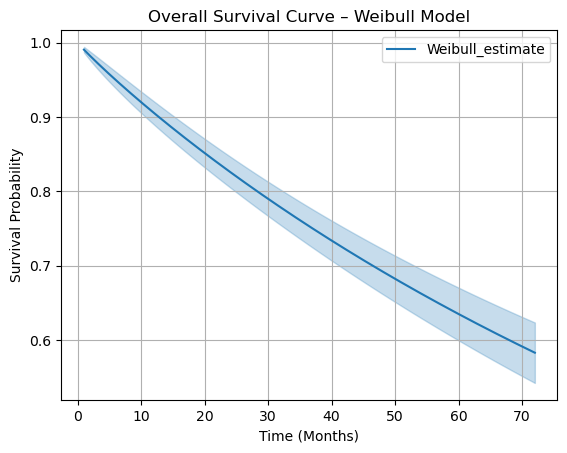

In [22]:
data_copy = data.copy()

print(data_copy["event_observed"].value_counts())

data_copy["tenure"] = pd.to_numeric(data_copy["tenure"], errors="coerce")

data_copy = data_copy.dropna(subset=["tenure", "event_observed"])

weibull_model = WeibullFitter()
weibull_model.fit(
    durations=data_copy["tenure"],
    event_observed=data_copy["event_observed"]
)
weibull_model.print_summary()

weibull_model.plot_survival_function()
plt.title("Overall Survival Curve – Weibull Model")
plt.xlabel("Time (Months)")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.show()

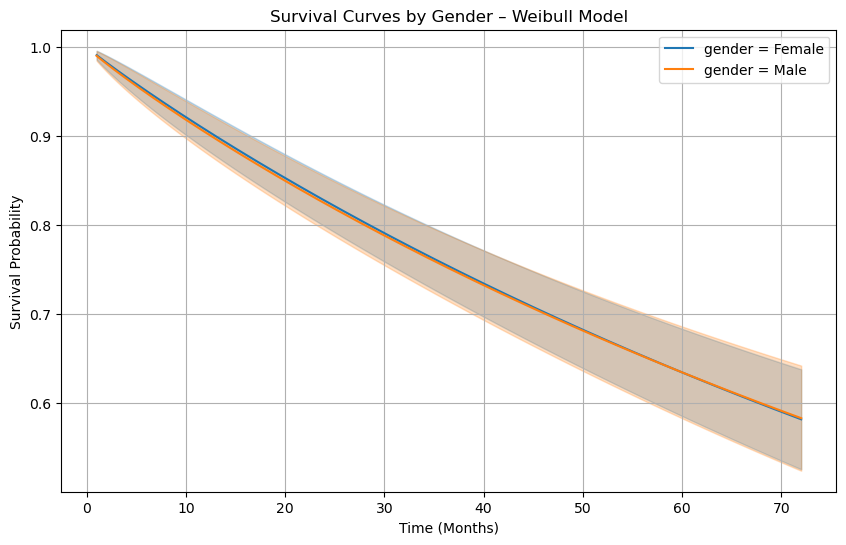

In [23]:
segment_col = "gender"

plt.figure(figsize=(10, 6))

for val in sorted(data_copy[segment_col].unique()):
    subset = data_copy[data_copy[segment_col] == val]
    weibull_segment_model = WeibullFitter()
    weibull_segment_model.fit(
        durations=subset["tenure"],
        event_observed=subset["event_observed"],
        label=f"{segment_col} = {val}"
    )
    weibull_segment_model.plot_survival_function()

plt.title(f"Survival Curves by {segment_col.capitalize()} – Weibull Model")
plt.xlabel("Time (Months)")
plt.ylabel("Survival Probability")
plt.legend()
plt.grid(True)
plt.show()

## Summary
The dataset includes 1,000 customers, of which 274 (27.4%) have churned and 726 (72.6%) have remained active. This balanced distribution provides a solid foundation for survival analysis by ensuring sufficient representation of both events (churns) and censored cases (non-churners). To model customer retention over time, the WeibullFitter was applied to estimate the overall survival function. Despite a warning related to the invertibility of the Hessian matrix—a common occurrence in survival models when there are tied events or limited variability—the model successfully produced stable estimates. The shape parameter (ρ ≈ 0.95) suggests an approximately constant hazard rate, implying that the risk of churn remains steady over a customer’s tenure rather than increasing or decreasing. The scale parameter (λ) was estimated to be around 138.09. The resulting survival curve shows a gradual decline in customer retention, with the probability of a customer remaining active dropping to about 60% at the 72-month (6-year) mark. This indicates a consistent, moderate rate of churn over time and highlights the need for sustained customer engagement strategies.

## CLV

                     CLV ($)
gender = Female  2762.912028
gender = Male    2757.213160


<Figure size 1000x600 with 0 Axes>

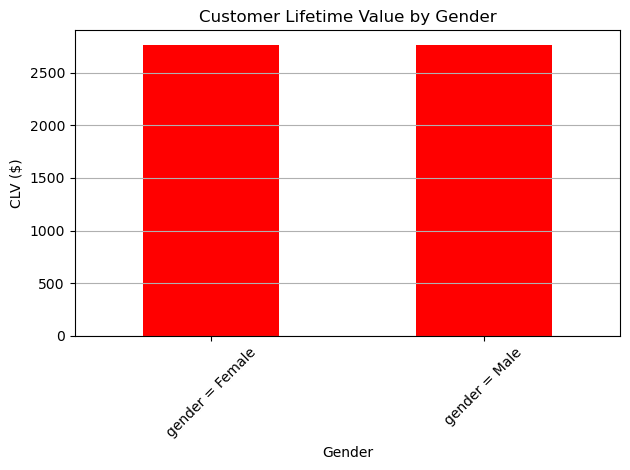

In [25]:
segment_clv = {}
monthly_revenue = 50  # Assumed monthly revenue per customer

for val in sorted(data_copy[segment_col].unique()):
    subset = data_copy[data_copy[segment_col] == val]
    segment_model = WeibullFitter()
    segment_model.fit(subset["tenure"], subset["event_observed"])

    time_range = np.linspace(0, 72, 200)  # Forecast up to 6 years (72 months)
    survival_probs = segment_model.survival_function_at_times(time_range)
    expected_lifetime = np.trapz(survival_probs.values.flatten(), time_range)
    clv = expected_lifetime * monthly_revenue

    segment_clv[f"{segment_col} = {val}"] = clv

clv_df = pd.DataFrame.from_dict(segment_clv, orient='index', columns=["CLV ($)"])
clv_df = clv_df.sort_values(by="CLV ($)", ascending=False)
print(clv_df)

custom_colors = {
    'Female': 'red',
    'Male': 'blue'
}

bar_colors = [custom_colors.get(label.split('=')[1].strip(), 'gray') for label in clv_df.index]

plt.figure(figsize=(10, 6))
clv_df.plot(
    kind='bar',
    legend=False,
    color=bar_colors
)
plt.title(f"Customer Lifetime Value by {segment_col.capitalize()}")
plt.xlabel(segment_col.capitalize())
plt.ylabel("CLV ($)")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## CLV Conclusion

Customer Lifetime Value (CLV) was estimated for male and female customer segments by calculating the area under each segment's survival curve and multiplying it by an assumed monthly revenue of $50 per customer. The results showed that female customers had a CLV of approximately 2762.912028 dollars, while male customers had a slightly lower CLV of 2757.213160 dollars. Although the difference is marginal, it suggests that female customers tend to have slightly longer retention. This aligns with the findings from the survival analysis, which indicated a modestly higher survival probability for female customers over time. These insights can support more effective marketing and retention strategies by helping businesses focus on customer segments with higher lifetime value.